In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from src import functions as fc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_cleaned = fc.load_data_clean("bank_full.csv")

Buscando archivo en: /Users/jbp/Desktop/IRONHACK/SEMANA7/ML_project/data/cleaned/bank_full.csv


In [4]:
df_yes = df_cleaned[df_cleaned["y"] == "yes"]

In [5]:
df_yes.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [6]:
columnas_perfil = ["age", "job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "duration"]
df_perfil = df_yes[columnas_perfil]

In [7]:
df_perfil

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration
75,41,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,1575
83,49,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,1042
88,49,technician,married,basic.9y,no,no,no,telephone,may,mon,1467
129,41,technician,married,professional.course,unknown,yes,no,telephone,may,mon,579
139,45,blue-collar,married,basic.9y,unknown,yes,no,telephone,may,mon,461
...,...,...,...,...,...,...,...,...,...,...,...
41162,62,retired,married,university.degree,no,yes,no,cellular,nov,thu,208
41166,62,retired,married,university.degree,no,no,no,cellular,nov,thu,483
41169,37,admin.,married,university.degree,no,yes,no,cellular,nov,fri,281
41171,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334


In [8]:
df_perfil.dtypes

age             int64
job            object
marital        object
education      object
default        object
housing        object
loan           object
contact        object
month          object
day_of_week    object
duration        int64
dtype: object

In [9]:
df_perfil["education"].unique()

array(['basic.4y', 'university.degree', 'basic.9y', 'professional.course',
       'unknown', 'high.school', 'basic.6y', 'illiterate'], dtype=object)

In [10]:
basicos = ['basic.4y', 'basic.9y', 'basic.6y', 'high.school']

df_perfil['education'] = df_perfil['education'].replace(basicos, 'basic')
df_perfil['education'] = df_perfil['education'].replace('university.degree', 'university')
df_perfil['education'] = df_perfil['education'].replace('professional.course', 'p.course')

/var/folders/p5/k72mxyjd6fq22gzlrpbtzhz40000gn/T/ipykernel_15088/1142857329.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_perfil['education'] = df_perfil['education'].replace(basicos, 'basic')
/var/folders/p5/k72mxyjd6fq22gzlrpbtzhz40000gn/T/ipykernel_15088/1142857329.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_perfil['education'] = df_perfil['education'].replace('university.degree', 'university')
/var/folders/p5/k72mxyjd6fq22gzlrpbtzhz40000gn/T/ipykernel_15088/1142857329.py:5: SettingWi

In [11]:
df_perfil["education"].unique()

array(['basic', 'university', 'p.course', 'unknown', 'illiterate'],
      dtype=object)

In [12]:
df_perfil["age"].unique()

array([41, 49, 45, 42, 39, 28, 44, 31, 37, 54, 46, 32, 43, 50, 51, 33, 38,
       60, 35, 24, 59, 30, 36, 27, 40, 53, 29, 56, 26, 57, 47, 48, 34, 52,
       58, 55, 25, 22, 23, 21, 70, 66, 88, 19, 77, 68, 20, 73, 62, 80, 63,
       82, 61, 69, 67, 71, 75, 64, 78, 65, 85, 79, 81, 18, 74, 76, 17, 87,
       72, 83, 98, 86, 84, 92, 89])

In [13]:
age_bins = [0, 30, 45, 60, np.inf]
age_labels = ["Young", "Adult", "Senior", "Elderly"]

df_perfil.loc[:, "age_category"] = pd.cut(df_perfil["age"], bins=age_bins, labels=age_labels, include_lowest=True)

/var/folders/p5/k72mxyjd6fq22gzlrpbtzhz40000gn/T/ipykernel_15088/117473743.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_perfil.loc[:, "age_category"] = pd.cut(df_perfil["age"], bins=age_bins, labels=age_labels, include_lowest=True)


In [14]:
df_perfil

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,age_category
75,41,blue-collar,divorced,basic,unknown,yes,no,telephone,may,mon,1575,Adult
83,49,entrepreneur,married,university,unknown,yes,no,telephone,may,mon,1042,Senior
88,49,technician,married,basic,no,no,no,telephone,may,mon,1467,Senior
129,41,technician,married,p.course,unknown,yes,no,telephone,may,mon,579,Adult
139,45,blue-collar,married,basic,unknown,yes,no,telephone,may,mon,461,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
41162,62,retired,married,university,no,yes,no,cellular,nov,thu,208,Elderly
41166,62,retired,married,university,no,no,no,cellular,nov,thu,483,Elderly
41169,37,admin.,married,university,no,yes,no,cellular,nov,fri,281,Adult
41171,73,retired,married,p.course,no,yes,no,cellular,nov,fri,334,Elderly


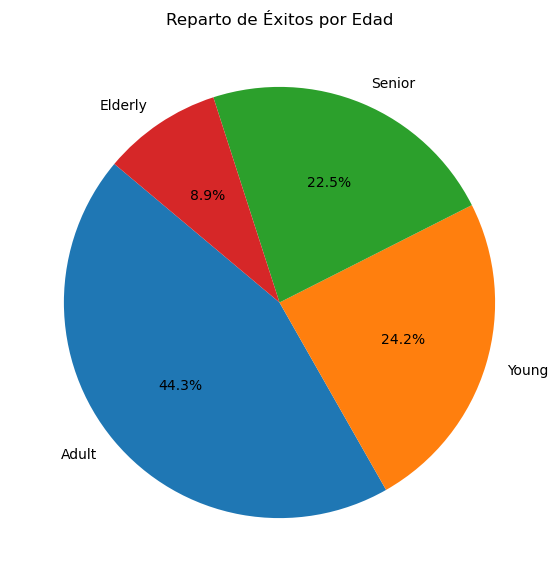

La mayoría de los éxitos están en: Adult


In [15]:
counts_age = df_perfil['age_category'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(counts_age, labels=counts_age.index, autopct='%1.1f%%', startangle=140)
plt.title("Reparto de Éxitos por Edad")
plt.show()

print(f"La mayoría de los éxitos están en: {counts_age.idxmax()}")

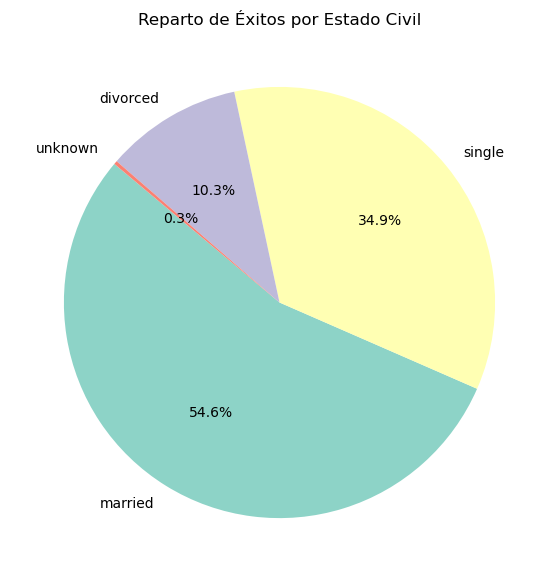

In [16]:
counts_marital = df_perfil['marital'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    counts_marital, 
    labels=counts_marital.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Set3")
)
plt.title("Reparto de Éxitos por Estado Civil")
plt.show()

/var/folders/p5/k72mxyjd6fq22gzlrpbtzhz40000gn/T/ipykernel_15088/2222553823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="viridis")


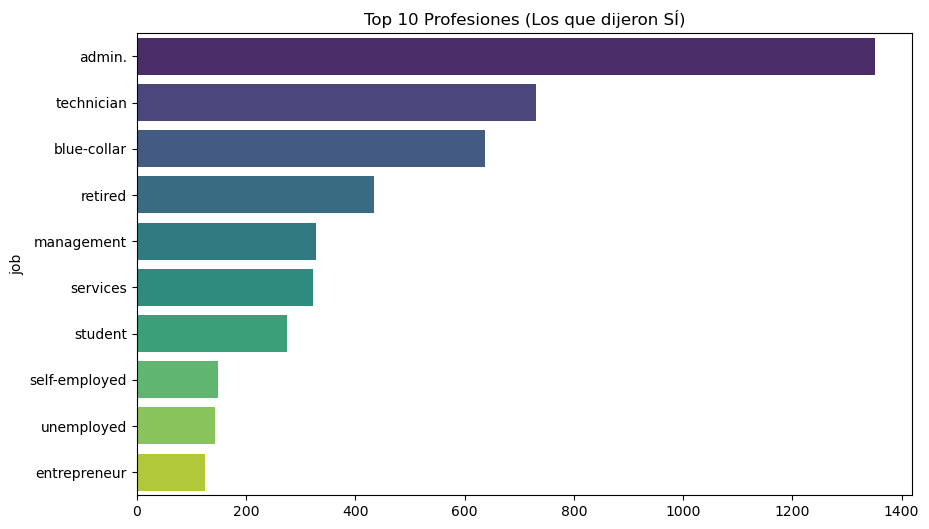

In [17]:
plt.figure(figsize=(10,6))
top_jobs = df_perfil['job'].value_counts().head(10)

sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="viridis")
plt.title("Top 10 Profesiones (Los que dijeron SÍ)")
plt.show()

/var/folders/p5/k72mxyjd6fq22gzlrpbtzhz40000gn/T/ipykernel_15088/175616428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_edu.index, y=counts_edu.values, palette="magma")


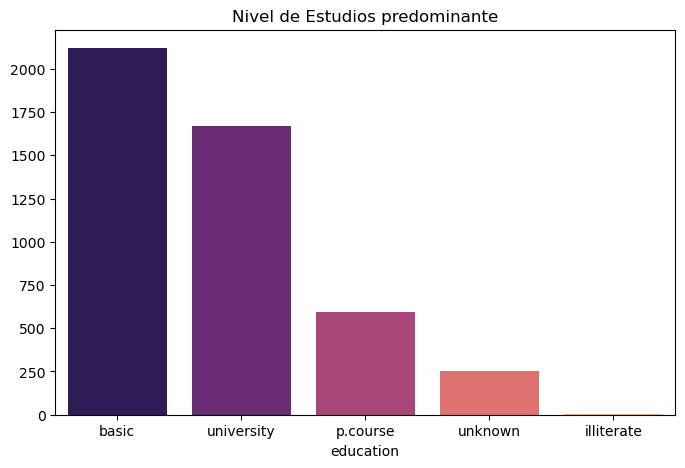

La mayoría tiene estudios de: basic


In [18]:
plt.figure(figsize=(8,5))
counts_edu = df_perfil['education'].value_counts()

sns.barplot(x=counts_edu.index, y=counts_edu.values, palette="magma")
plt.title("Nivel de Estudios predominante")
plt.show()

print(f"La mayoría tiene estudios de: {counts_edu.idxmax()}")

In [19]:
for columna in ['loan', 'housing', 'default']:
    print(f"Variable {columna.upper()}:")
    print(df_perfil[columna].value_counts())
    print(f"La mayoría está en: {df_perfil[columna].mode()[0]}")
    print("-" * 20)

Variable LOAN:
loan
no         3849
yes         683
unknown     107
Name: count, dtype: int64
La mayoría está en: no
--------------------
Variable HOUSING:
housing
yes        2507
no         2025
unknown     107
Name: count, dtype: int64
La mayoría está en: yes
--------------------
Variable DEFAULT:
default
no         4196
unknown     443
Name: count, dtype: int64
La mayoría está en: no
--------------------


Ranking de Meses:
month
may    886
aug    655
jul    648
jun    559
apr    539
nov    416
oct    315
mar    276
sep    256
dec     89
Name: count, dtype: int64

Ranking de Días:
day_of_week
thu    1044
tue     953
wed     949
mon     847
fri     846
Name: count, dtype: int64


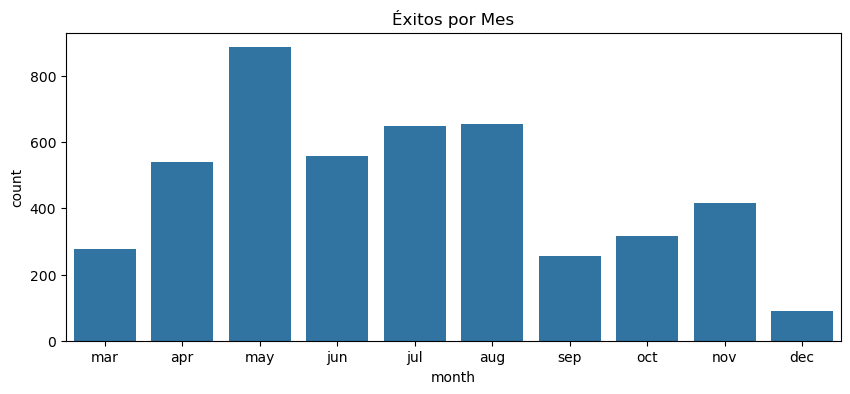

In [20]:
mejor_mes = df_perfil['month'].value_counts()
print("Ranking de Meses:")
print(mejor_mes)

mejor_dia = df_perfil['day_of_week'].value_counts()
print("\nRanking de Días:")
print(mejor_dia)

plt.figure(figsize=(10,4))
sns.countplot(x='month', data=df_perfil, order=['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
plt.title("Éxitos por Mes")
plt.show()